In [1]:


from pathlib import Path
import sys
import warnings


warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "Exploration" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from Models.MDP import GolfHoleMDP
from Simulation.HoleSetUp.hole_simple import create_hole

print(f"Project root: {PROJECT_ROOT}")
from Utils.DataManager import load_data
from Models.GaussianMixture import GaussianMixtureModel

/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/epicxflipper/UBC/CPSC440/CPSC_440_Project/Backend


Loading club models: []
Using device: cpu
Initialized MDP: 1271 states, 0 clubs
Loading club models: ['Ryan_I7', 'universal_wedge']


9

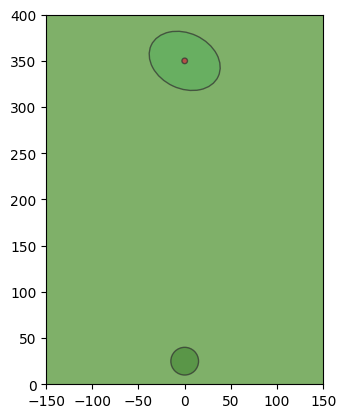

In [4]:
mdp = GolfHoleMDP()
mdp.load("string")
score = mdp.simulate_score((0, 0))
score

In [ ]:
dataset = load_data("project_data")

# Fit one GMM per club from Data/RG_Data.csv.
# We model each shot as [lateral_offset, distance].


DATA_PATH = PROJECT_ROOT / "Data" / "RG_Data.csv"
PLAYER_NAME = "2"
MAX_COMPONENTS = 10
MIN_SHOTS_PER_CLUB = 50

raw = preprocess_data()
player_df = raw[raw["Name"] == PLAYER_NAME].copy()

if player_df.empty:
    raise ValueError(f"No rows found for player '{PLAYER_NAME}' in {DATA_PATH}.")

clubs = []

for club, club_df in sorted(player_df.groupby("Club"), key=lambda x: x[0]):
    if len(club_df) < MIN_SHOTS_PER_CLUB:
        continue

    club_data = club_df.dropna(subset=["X", "Y"]).copy()
    gmm = GaussianMixtureModel(max_components=MAX_COMPONENTS)
    gmm.fit(club_data)

    clubs.append(gmm)
    

if not clubs:
    raise ValueError(
        "No club had enough shots to fit a GMM. Lower MIN_SHOTS_PER_CLUB or collect more data."
    )

print(f"Player: {PLAYER_NAME}")
print(f"Clubs used ({len(clubs)}): {list(player_df['Club'].unique())}")

Combined dataset shape: (1633, 4)
Combined dataset shape: (1633, 4)
Player: 2
Clubs used (2): ['W1', 'I7']


In [2]:
club = GaussianMixtureModel()
club.load("Ryan_I7")
clubs = [club]

In [8]:
from sklearn.mixture import GaussianMixture
import numpy as np

# Create a single-component Gaussian mixture model
gmm = GaussianMixture(n_components=1, random_state=42)

gmm.weights_ = np.array([1.0])  
gmm.means_ = np.array([[0, 15]]) 
gmm.covariances_ = np.array([[[2, 0],
                               [0, 2]]])

mixture_model = GaussianMixtureModel(max_components=1)
mixture_model.gmm = gmm
mixture_model.num_components = 1
mixture_model.save("universal_wedge")

In [3]:
clubs

Loading club models: ['Ryan_I7', 'universal_wedge']
Using device: cpu
Initialized MDP: 1271 states, 2 clubs
Building transition matrices...


Building transitions: 100%|██████████| 1271/1271 [01:03<00:00, 20.09it/s]


Built transitions for 1271 states


Value iteration:  64%|██████▍   | 32/50 [00:20<00:11,  1.57it/s, delta=0.000001]



Converged after 33 iterations


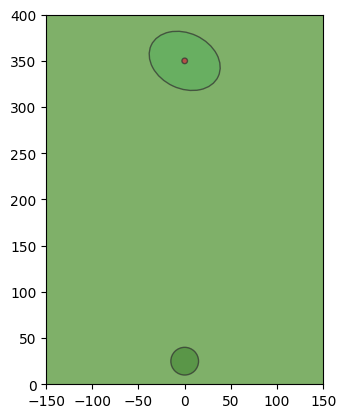

In [10]:
# Create clubs
clubs = ["Ryan_I7", "universal_wedge"]

hole = create_hole()

# Create MDP
mdp = GolfHoleMDP(hole, clubs, grid_step=10, device="cpu")

# Solve
value_function, policy = mdp.solve(num_samples=100, max_iterations=50, gamma=0.98)

In [12]:
"""
Visualization utilities for golf MDP results.
Creates heatmaps and policy visualizations overlaid on hole renderings.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def create_value_heatmap(mdp, value_function, output_path=None, show_plot=True):
    """
    Create a heatmap showing expected strokes remaining from each position.
    
    Args:
        mdp: GolfHoleMDP instance
        value_function: Dict mapping states to values
        output_path: Optional path to save figure
        show_plot: Whether to display the plot
    
    Returns:
        fig, ax: Matplotlib figure and axes
    """
    # Render the hole first
    fig, ax = mdp.hole.draw()
    
    # Create grid for heatmap
    nx = len(mdp.grid_x)
    ny = len(mdp.grid_y)
    
    score_grid = np.zeros((ny, nx))
    
    for i, y in enumerate(mdp.grid_y):
        for j, x in enumerate(mdp.grid_x):
            state = (float(x), float(y))
            value = value_function.get(state, 0.0)
            score_grid[i, j] = max(0.0, -value)
    
    # Overlay heatmap
    extent = [mdp.grid_x[0], mdp.grid_x[-1], mdp.grid_y[0], mdp.grid_y[-1]]
    
    im = ax.imshow(
        score_grid,
        extent=extent,
        origin='lower',
        cmap='YlOrRd',
        alpha=0.6,
        aspect='auto',
        interpolation='bilinear',
        vmin=0,
        vmax=np.percentile(score_grid[score_grid > 0], 95) if np.any(score_grid > 0) else 10
    )
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Expected Strokes Remaining', fontsize=10)
    
    # Mark tee and pin
    ax.scatter(
        [mdp.tee_location[0]], 
        [mdp.tee_location[1]], 
        c='white', 
        s=150, 
        marker='o',
        edgecolors='black', 
        linewidths=2,
        label='Tee',
        zorder=10
    )
    
    ax.scatter(
        [mdp.pin_location[0]], 
        [mdp.pin_location[1]], 
        c='red', 
        s=150, 
        marker='*',
        edgecolors='black', 
        linewidths=1.5,
        label='Pin',
        zorder=10
    )
    
    # Mark terminal radius
    terminal_circle = plt.Circle(
        mdp.pin_location,
        mdp.terminal_radius,
        color='red',
        fill=False,
        linestyle='--',
        linewidth=2,
        alpha=0.5,
        label=f'Terminal ({mdp.terminal_radius}yd)',
        zorder=5
    )
    ax.add_patch(terminal_circle)
    
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title('Expected Strokes to Hole Out', fontsize=12, fontweight='bold')
    
    if output_path:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved heatmap to {output_path}")
    
    if show_plot:
        plt.show()
    
    return fig, ax


def create_policy_visualization(mdp, policy, value_function, club_names, output_path=None, show_plot=True):
    """
    Visualize the optimal policy with arrows showing recommended shots.
    
    Args:
        mdp: GolfHoleMDP instance
        policy: Dict mapping states to actions
        value_function: Dict mapping states to values
        club_names: List of club names
        output_path: Optional path to save figure
        show_plot: Whether to display the plot
    
    Returns:
        fig, ax: Matplotlib figure and axes
    """
    fig, ax = mdp.hole.draw()
    
    # Sample states to avoid overcrowding
    sample_step = max(1, mdp.grid_step * 2)
    sample_x = mdp.grid_x[::max(1, int(sample_step / mdp.grid_step))]
    sample_y = mdp.grid_y[::max(1, int(sample_step / mdp.grid_step))]
    
    for x in sample_x:
        for y in sample_y:
            state = (float(x), float(y))
            
            if mdp.is_terminal(state):
                continue
            
            action = policy.get(state)
            if action is None:
                continue
            
            club_idx, target_x, target_y = action
            
            # Draw arrow to target
            dx = target_x - x
            dy = target_y - y
            
            # Limit arrow length for visibility
            arrow_length = min(np.sqrt(dx**2 + dy**2), 50)
            if arrow_length > 1:
                dx_norm = dx / np.sqrt(dx**2 + dy**2) * arrow_length
                dy_norm = dy / np.sqrt(dx**2 + dy**2) * arrow_length
                
                ax.arrow(
                    x, y, dx_norm, dy_norm,
                    head_width=3,
                    head_length=5,
                    fc='blue',
                    ec='blue',
                    alpha=0.4,
                    linewidth=1,
                    zorder=4
                )
    
    ax.scatter(
        [mdp.tee_location[0]], 
        [mdp.tee_location[1]], 
        c='white', 
        s=150, 
        marker='o',
        edgecolors='black', 
        linewidths=2,
        label='Tee',
        zorder=10
    )
    
    ax.scatter(
        [mdp.pin_location[0]], 
        [mdp.pin_location[1]], 
        c='red', 
        s=150, 
        marker='*',
        edgecolors='black', 
        linewidths=1.5,
        label='Pin',
        zorder=10
    )
    
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title('Optimal Policy (Blue Arrows)', fontsize=12, fontweight='bold')
    
    if output_path:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved policy visualization to {output_path}")
    
    if show_plot:
        plt.show()
    
    return fig, ax


def print_statistics(mdp, value_function, policy):
    """Print summary statistics about the solution."""
    
    print("\n" + "="*70)
    print("MDP SOLUTION STATISTICS")
    print("="*70)
    
    # Value statistics
    values = [v for v in value_function.values() if v < 0]
    if values:
        expected_strokes = [-v for v in values]
        print(f"\nExpected Strokes (non-terminal states):")
        print(f"  Min:    {min(expected_strokes):.2f}")
        print(f"  Max:    {max(expected_strokes):.2f}")
        print(f"  Mean:   {np.mean(expected_strokes):.2f}")
        print(f"  Median: {np.median(expected_strokes):.2f}")
    
    # Tee statistics
    tee_state = mdp._snap_to_grid(*mdp.tee_location)
    tee_value = value_function.get(tee_state, 0.0)
    print(f"\nFrom Tee ({tee_state}):")
    print(f"  Expected strokes: {-tee_value:.2f}")
    
    tee_action = policy.get(tee_state)
    if tee_action:
        club_idx, target_x, target_y = tee_action
        print(f"  Recommended club: #{club_idx}")
        print(f"  Aim at: ({target_x:.1f}, {target_y:.1f})")
    
    # Terminal state count
    terminal_count = sum(1 for s in mdp.states if mdp.is_terminal(s))
    print(f"\nTerminal states: {terminal_count} / {mdp.num_states}")
    
    # Policy coverage
    non_terminal_states = [s for s in mdp.states if not mdp.is_terminal(s)]
    states_with_policy = sum(1 for s in non_terminal_states if policy.get(s) is not None)
    print(f"States with policy: {states_with_policy} / {len(non_terminal_states)}")
    
    print("="*70 + "\n")


def simulate_trajectory(mdp, policy, club_names, start_state=None, max_shots=20):
    """
    Simulate playing the hole following the policy.
    
    Args:
        mdp: GolfHoleMDP instance
        policy: Computed policy
        club_names: List of club names
        start_state: Starting position (default: tee)
        max_shots: Maximum shots to prevent infinite loops
    
    Returns:
        List of dicts with shot information
    """
    if start_state is None:
        start_state = mdp._snap_to_grid(*mdp.tee_location)
    
    trajectory = []
    current_state = start_state
    
    print("\n" + "="*70)
    print("SIMULATING HOLE PLAY")
    print("="*70)
    
    for shot_num in range(max_shots):
        if mdp.is_terminal(current_state):
            print(f"\n✓ Hole completed in {shot_num} shots!")
            break
        
        action = policy.get(current_state)
        if action is None:
            print(f"\nNo policy for state {current_state}")
            break
        
        club_idx, target_x, target_y = action
        
        print(f"\nShot {shot_num + 1}:")
        print(f"  Position: ({current_state[0]:.1f}, {current_state[1]:.1f})")
        print(f"  Distance to pin: {np.linalg.norm(np.array(current_state) - mdp.pin_location):.1f} yards")
        print(f"  Club: {club_names[club_idx]}")
        print(f"  Aim at: ({target_x:.1f}, {target_y:.1f})")
        
        # Take one sample shot
        reward, next_dist = mdp.simulate_shot(current_state, action, num_samples=1)
        next_state = list(next_dist.keys())[0]
        
        trajectory.append({
            'shot': shot_num + 1,
            'from': current_state,
            'club': club_names[club_idx],
            'target': (target_x, target_y),
            'landed': next_state,
            'reward': reward
        })
        
        print(f"  → Landed at ({next_state[0]:.1f}, {next_state[1]:.1f})")
        
        current_state = next_state
    
    print("="*70 + "\n")
    return trajectory

Saved heatmap to Output/value_heatmap.png


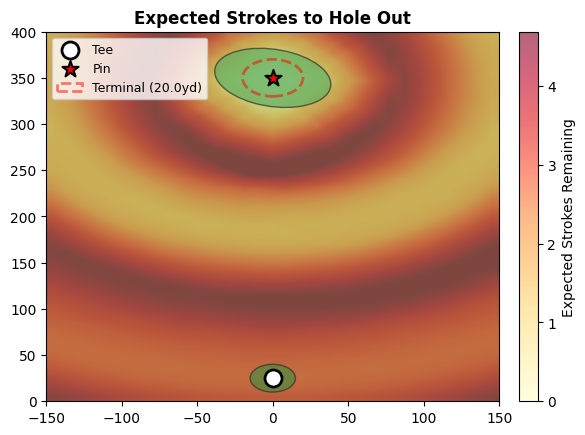

Saved policy visualization to Output/policy_arrows.png


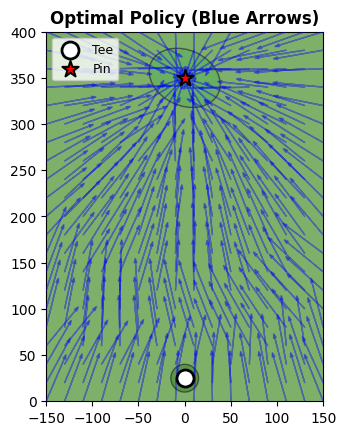


MDP SOLUTION STATISTICS

Expected Strokes (non-terminal states):
  Min:    1.00
  Max:    5.43
  Mean:   3.23
  Median: 3.25

From Tee ((0.0, 20.0)):
  Expected strokes: 3.10
  Recommended club: #0
  Aim at: (23.7, 218.6)

Terminal states: 13 / 1271
States with policy: 1258 / 1258


SIMULATING HOLE PLAY

Shot 1:
  Position: (0.0, 20.0)
  Distance to pin: 330.0 yards
  Club: Iron (50yd)
  Aim at: (23.7, 218.6)
  → Landed at (10.0, 70.0)

Shot 2:
  Position: (10.0, 70.0)
  Distance to pin: 280.2 yards
  Club: Iron (50yd)
  Aim at: (-48.6, 261.2)
  → Landed at (0.0, 120.0)

Shot 3:
  Position: (0.0, 120.0)
  Distance to pin: 230.0 yards
  Club: Iron (50yd)
  Aim at: (4.8, 319.9)
  → Landed at (10.0, 170.0)

Shot 4:
  Position: (10.0, 170.0)
  Distance to pin: 180.3 yards
  Club: Iron (50yd)
  Aim at: (3.7, 369.9)
  → Landed at (10.0, 220.0)

Shot 5:
  Position: (10.0, 220.0)
  Distance to pin: 130.4 yards
  Club: Iron (50yd)
  Aim at: (0.0, 350.0)
  → Landed at (10.0, 270.0)

Shot 6:
  P

In [13]:
club_names = [ 'Iron (50yd)', 'Wedge (≤50yd)']

create_value_heatmap(mdp, value_function, output_path='Output/value_heatmap.png')
create_policy_visualization(mdp, policy, value_function, club_names, output_path='Output/policy_arrows.png')

# Statistics
print_statistics(mdp, value_function, policy)

# Simulate a round
trajectory = simulate_trajectory(mdp, policy, club_names)

In [3]:
value_function

{(-150.0, 0.0): -3.881592035293579,
 (-150.0, 10.0): -3.881592035293579,
 (-150.0, 20.0): -3.881592035293579,
 (-150.0, 30.0): -3.881592035293579,
 (-150.0, 40.0): -3.881592035293579,
 (-150.0, 50.0): -3.881592035293579,
 (-150.0, 60.0): -2.9404001235961914,
 (-150.0, 70.0): -2.9404001235961914,
 (-150.0, 80.0): -2.9404001235961914,
 (-150.0, 90.0): -2.9404001235961914,
 (-150.0, 100.0): -2.9404001235961914,
 (-150.0, 110.0): -2.9404001235961914,
 (-150.0, 120.0): -2.9404001235961914,
 (-150.0, 130.0): -2.9404001235961914,
 (-150.0, 140.0): -2.9404001235961914,
 (-150.0, 150.0): -2.9404001235961914,
 (-150.0, 160.0): -2.9404001235961914,
 (-150.0, 170.0): -2.9404001235961914,
 (-150.0, 180.0): -2.9404001235961914,
 (-150.0, 190.0): -2.9404001235961914,
 (-150.0, 200.0): -1.9800000190734863,
 (-150.0, 210.0): -1.9800000190734863,
 (-150.0, 220.0): -1.9800000190734863,
 (-150.0, 230.0): -1.9800000190734863,
 (-150.0, 240.0): -1.9800000190734863,
 (-150.0, 250.0): -1.9800000190734863,
 (-

In [21]:
def simulate_hole():
    terminal = False
    state = mdp._snap_to_grid(*mdp.tee_location)
    shots = 0
    print("state: ", state)
    while not terminal and shots < 100:
        action = policy.get(state)
        if action is None:
            print(f"No policy for state {state}")
            break
        
        reward, next_dist = mdp.simulate_shot(state, action, num_samples=1)
        state = list(next_dist.keys())[0]
        terminal = mdp.is_terminal(state)
        shots += 1
        print(f"action taken: {action}, new state: {state}, terminal: {terminal}")

    return shots, state, terminal

shots, state, terminal = simulate_hole()
print(f"Simulated hole: {shots} shots, final state: {state}, terminal: {terminal}")

state:  (0.0, 20.0)
action taken: (0, np.float32(0.0), np.float32(350.0)), new state: (0.0, 120.0), terminal: False
action taken: (0, 51.76380902050415, 313.18516525781365), new state: (30.0, 220.0), terminal: False
action taken: (0, 88.49231055274959, 411.2554564089629), new state: (60.0, 320.0), terminal: False
action taken: (0, 4.5577136594005125, 403.97114317029974), new state: (60.0, 320.0), terminal: False
action taken: (0, 4.5577136594005125, 403.97114317029974), new state: (60.0, 320.0), terminal: False
action taken: (0, 4.5577136594005125, 403.97114317029974), new state: (60.0, 320.0), terminal: False
action taken: (0, 4.5577136594005125, 403.97114317029974), new state: (60.0, 320.0), terminal: False
action taken: (0, 4.5577136594005125, 403.97114317029974), new state: (60.0, 320.0), terminal: False
action taken: (0, 4.5577136594005125, 403.97114317029974), new state: (60.0, 320.0), terminal: False
action taken: (0, 4.5577136594005125, 403.97114317029974), new state: (60.0, 32

In [22]:
state = (60.0, 320.0)
actions = mdp.get_actions(state)

print(f"State: {state}")
print(f"Distance to pin: {np.linalg.norm(np.array(state) - mdp.pin_location):.2f}")
print(f"Total actions: {len(actions)}\n")

gamma = 0.98

# Find "aim at pin" actions for each club
for club_idx in range(3):
    pin_actions = [a for a in actions if a[0] == club_idx and 
                   abs(a[1] - mdp.pin_location[0]) < 0.1 and 
                   abs(a[2] - mdp.pin_location[1]) < 0.1]
    
    if pin_actions:
        action = pin_actions[0]
        print(f"Club {club_idx} aiming at pin:")
        
        reward, next_dist = mdp.simulate_shot(state, action, num_samples=100)
        print(f"  Reward: {reward:.3f}")
        print(f"  Next states: {len(next_dist)}")
        
        for ns, prob in sorted(next_dist.items(), key=lambda x: -x[1])[:3]:
            is_term = mdp.is_terminal(ns)
            dist = np.linalg.norm(np.array(ns) - mdp.pin_location)
            val = value_function.get(ns, 0.0)
            print(f"    {ns}: prob={prob:.3f}, terminal={is_term}, dist={dist:.1f}, value={val:.3f}")
        
        exp_next_val = sum(prob * value_function.get(ns, 0.0) for ns, prob in next_dist.items())
        q_val = reward + gamma * exp_next_val
        print(f"  Q-value: {q_val:.3f}\n")
    else:
        print(f"Club {club_idx}: NO 'aim at pin' action found!\n")

# Show what policy actually chose
policy_action = policy.get(state)
print(f"Policy chose: {policy_action}")

State: (60.0, 320.0)
Distance to pin: 67.08
Total actions: 18

Club 0 aiming at pin:
  Reward: -1.000
  Next states: 1
    (np.float32(0.0), np.float32(350.0)): prob=1.000, terminal=True, dist=0.0, value=0.000
  Q-value: -1.000

Club 1 aiming at pin:
  Reward: -1.000
  Next states: 1
    (np.float32(0.0), np.float32(350.0)): prob=1.000, terminal=True, dist=0.0, value=0.000
  Q-value: -1.000

Club 2 aiming at pin:
  Reward: -1.000
  Next states: 1
    (np.float32(0.0), np.float32(350.0)): prob=1.000, terminal=True, dist=0.0, value=0.000
  Q-value: -1.000

Policy chose: (0, 4.5577136594005125, 403.97114317029974)


In [23]:
state = (60.0, 320.0)

# Get actions twice
actions1 = mdp.get_actions(state)
actions2 = mdp.get_actions(state)

print("First call:")
for i, a in enumerate(actions1[:5]):
    print(f"  {i}: {a}")

print("\nSecond call:")
for i, a in enumerate(actions2[:5]):
    print(f"  {i}: {a}")

print("\nAre they identical?", actions1 == actions2)
print("Element-wise comparison:")
for i in range(min(5, len(actions1))):
    print(f"  {i}: {actions1[i] == actions2[i]}")

First call:
  0: (0, np.float32(0.0), np.float32(350.0))
  1: (0, 4.5577136594005125, 403.97114317029974)
  2: (0, -15.286467336402694, 386.760376242235)
  3: (0, -30.0, 365.0)
  4: (0, -38.58018139562958, 340.1729481237812)

Second call:
  0: (0, np.float32(0.0), np.float32(350.0))
  1: (0, 4.5577136594005125, 403.97114317029974)
  2: (0, -15.286467336402694, 386.760376242235)
  3: (0, -30.0, 365.0)
  4: (0, -38.58018139562958, 340.1729481237812)

Are they identical? True
Element-wise comparison:
  0: True
  1: True
  2: True
  3: True
  4: True
